# 🧮 unitary
**Obtiene y visualiza la matriz unitaria de un circuito cuántico.**

Usa `qiskit.quantum_info.Operator` para extraer la matriz $U \in \mathbb{C}^{2^n \times 2^n}$
correspondiente a cualquier `QuantumCircuit`.

> ⚠️ **Convención Qiskit (little-endian)**: `q[0]` es el bit *menos* significativo.
> La fila/columna $k$ corresponde al estado base $|k\rangle$ leído de derecha a izquierda.
>
> ⚠️ El circuito **no puede tener mediciones** antes de calcular la unitaria.
> Usa `remove_final_measurements()` si es necesario.

## 📦 1. Instalación de dependencias

In [1]:
try:
    import qiskit
    print(f"✅ Qiskit {qiskit.__version__} ya instalado")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "qiskit", "qiskit-aer", "pylatexenc", "-q"])
    print("✅ Qiskit instalado correctamente")

✅ Qiskit 2.4.1 ya instalado


## 📚 2. Imports

In [2]:
import json
import math
from shared import *
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Operator
from qiskit.circuit.library import (
    RZGate, RYGate, XGate, CXGate, HGate, ZGate, SGate, TGate,
)

print("✅ Imports OK")

✅ Imports OK


### Nivel 1 (4 qubits → matriz 16×16)

In [5]:

## with open("circuito.json", "r") as f:
##    data6 = json.load(f)

## qc6   = parse_json_to_circuit(data6)
## U1 = get_unitary(qc6)
dimensions = 16

# Generate random Hermitian matrix
H = 2 * np.random.rand(dimensions, dimensions) - np.ones((dimensions, dimensions))
H = H + 2j * (2 * np.random.rand(dimensions, dimensions) - np.ones((dimensions, dimensions)))
H = H + H.conj().T  # Hermitian matrix

U1 = np.array(np.linalg.eigh(H)[1])  # U is unitary (columns are eigenvectors)

print(f"⚛️  circuito.json — {U1.shape[0]}×{U1.shape[1]} unitaria")
print("Módulos (valores ~0 truncados a 0):")
print(np.round(U1, 4))
#print(np.where(np.abs(U6) < 1e-8, 0, np.round(np.abs(U6), 4)))

⚛️  circuito.json — 16×16 unitaria
Módulos (valores ~0 truncados a 0):
[[-0.1692+0.000e+00j -0.1826+0.000e+00j  0.2294+0.000e+00j
   0.4191+0.000e+00j -0.2027+0.000e+00j  0.2682+0.000e+00j
  -0.141 +0.000e+00j -0.2496+0.000e+00j -0.1054+0.000e+00j
   0.4347+0.000e+00j  0.2297+0.000e+00j  0.1429+0.000e+00j
  -0.1488+0.000e+00j  0.3515+0.000e+00j -0.2495+0.000e+00j
   0.1829+0.000e+00j]
 [-0.1772-5.150e-02j -0.2447+3.164e-01j -0.1285+1.890e-02j
  -0.1684+6.510e-02j -0.0102+5.460e-02j  0.0039+2.948e-01j
  -0.0377+7.090e-02j -0.012 +2.324e-01j  0.1438+3.335e-01j
  -0.3553+8.550e-02j  0.3121+8.520e-02j  0.1635+1.181e-01j
  -0.0167-1.015e-01j  0.2208-2.146e-01j  0.1006-2.047e-01j
   0.1833-6.420e-02j]
 [ 0.3064+3.610e-02j -0.0917-3.669e-01j  0.1699-6.860e-02j
   0.0568+2.167e-01j  0.1083+1.538e-01j -0.0742+9.960e-02j
  -0.0048+1.175e-01j -0.3347+1.579e-01j  0.0279+1.810e-02j
  -0.0672+9.150e-02j  0.316 -2.798e-01j -0.1627+1.180e-02j
   0.1478-2.239e-01j  0.0118-7.770e-02j  0.0357+3.760e-02j


In [6]:
dim=U1.shape[0]
n_qubits = int(np.log2(dim))
qc = QuantumCircuit(n_qubits)

qc.unitary(U1, range(n_qubits))
qc.draw()


┌──────────┐
q_0: ┤0         ├
     │          │
q_1: ┤1         ├
     │  Unitary │
q_2: ┤2         ├
     │          │
q_3: ┤3         ├
     └──────────┘

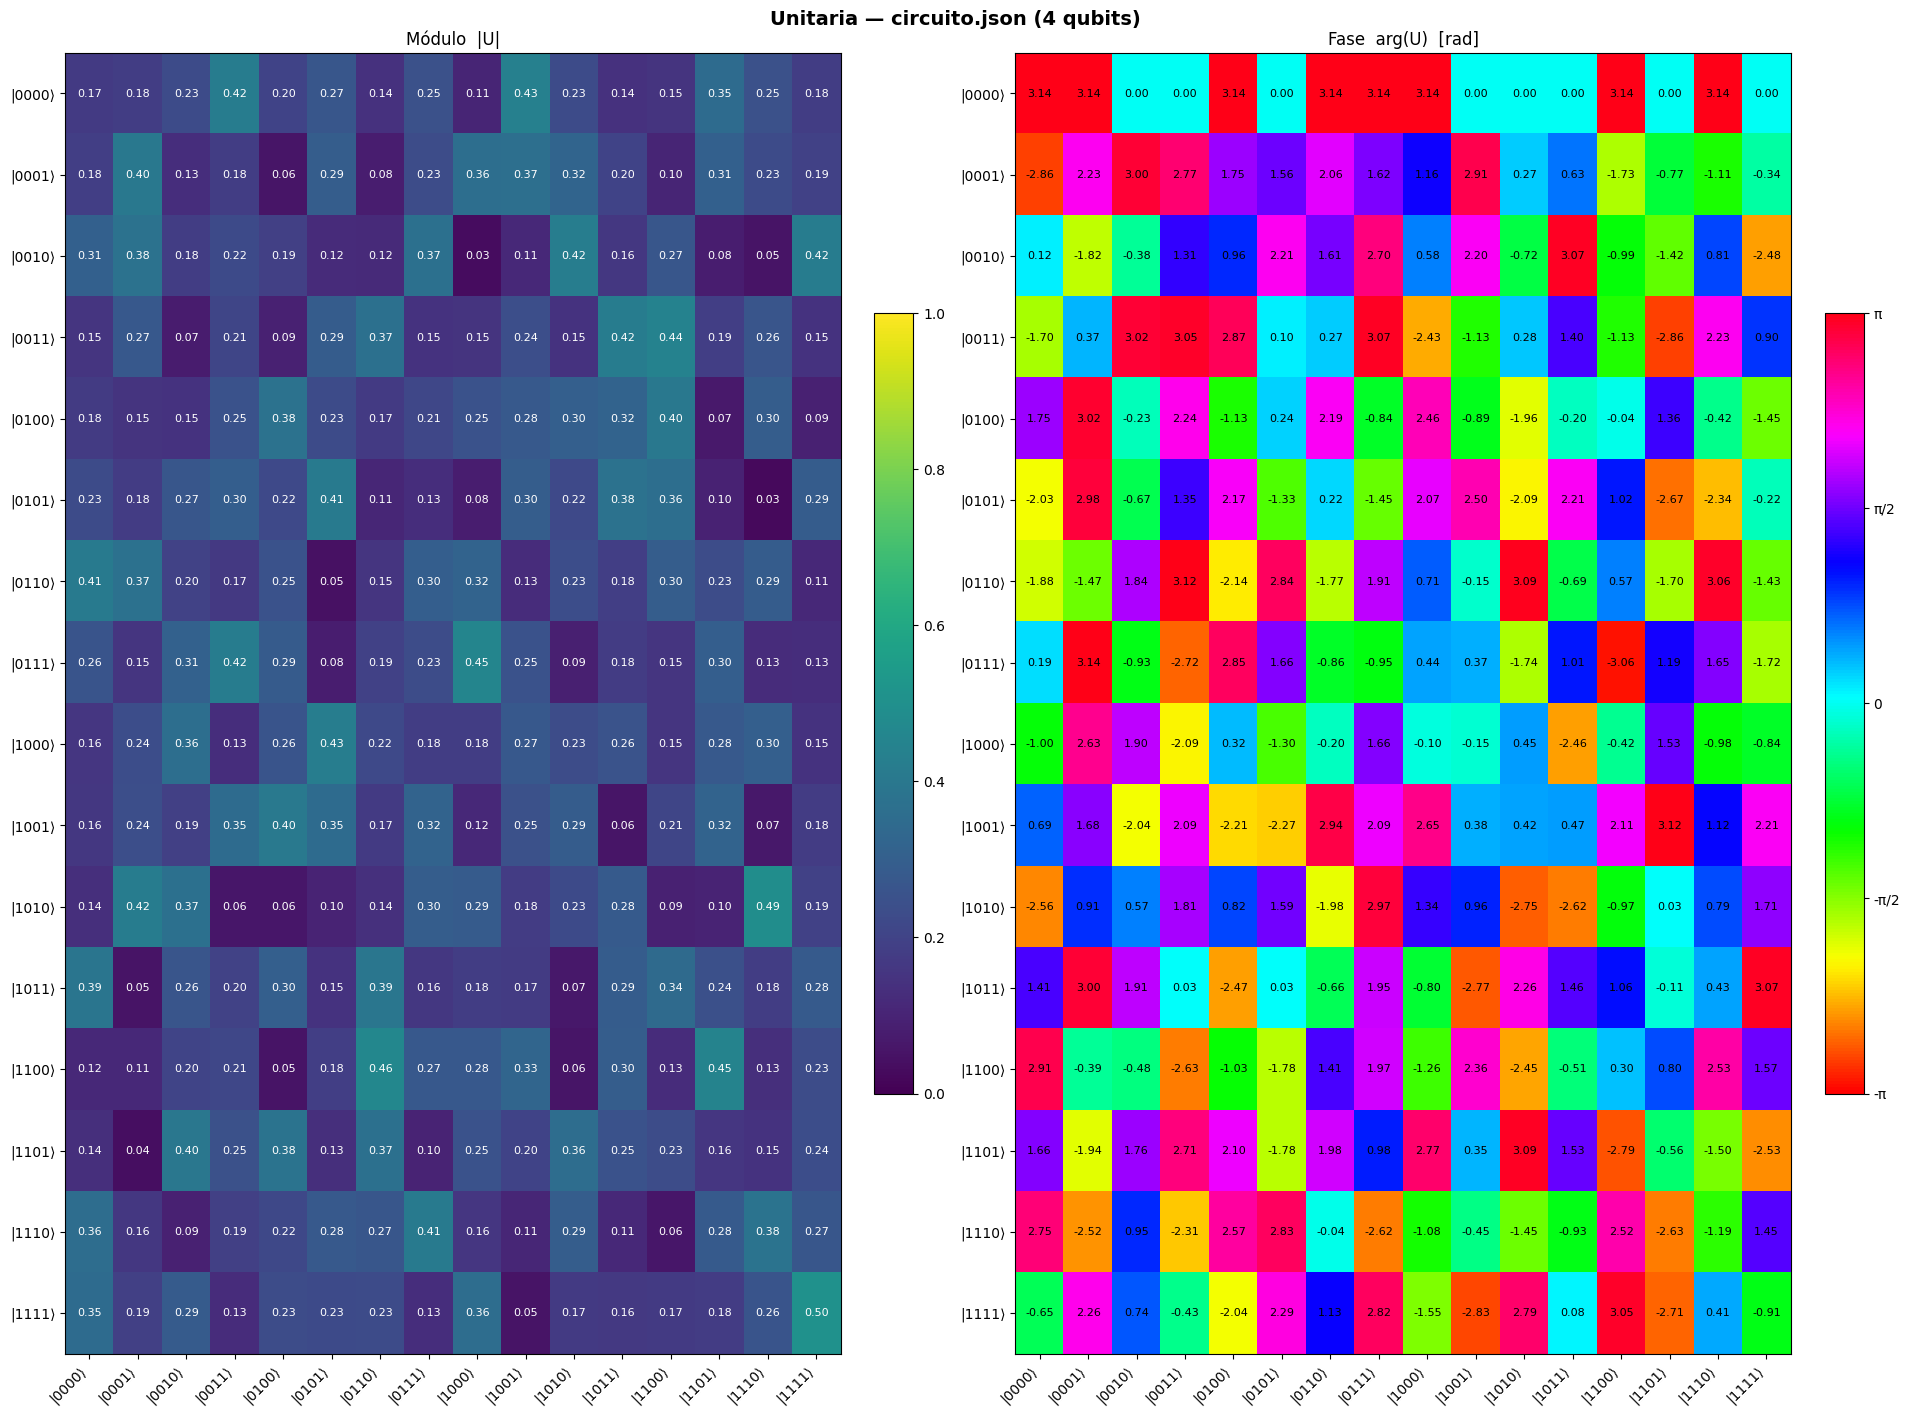

In [7]:
plot_unitary(U1, title="Unitaria — circuito.json (4 qubits)")

In [8]:
nivel2=decompose_unitary_to_mc(U1)

# Calcular e imprimir la profundidad
print(f"La profundidad del circuito es: {nivel2.depth()}")

nivel2.draw()

La profundidad del circuito es: 1135


┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐           ┌───┐┌───┐     ┌───┐»
q_0: ┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├─────■─────┤ X ├┤ X ├──■──┤ X ├»
     └─┬─┘└───┘┌─┴─┐├───┤└───┘  │  ├───┤├───┤     │     ├───┤├───┤  │  ├───┤»
q_1: ──■───────┤ X ├┤ X ├───────■──┤ X ├┤ X ├─────■─────┤ X ├┤ X ├──■──┤ X ├»
       │       └─┬─┘└───┘     ┌─┴─┐├───┤└───┘     │     ├───┤└───┘┌─┴─┐└───┘»
q_2: ──■─────────■────────────┤ X ├┤ X ├──────────■─────┤ X ├─────┤ X ├─────»
       │         │            └─┬─┘└───┘     ┌────┴────┐└───┘     └─┬─┘     »
q_3: ──■─────────■──────────────■────────────┤ Unitary ├────────────■───────»
                                             └─────────┘                    »
«     ┌───┐     ┌───┐┌───┐┌─────────┐                ┌───┐┌───┐           ┌───┐»
«q_0: ┤ X ├──■──┤ X ├┤ X ├┤ Unitary ├─────■──────────┤ X ├┤ X ├─────■─────┤ X ├»
«     └───┘┌─┴─┐└───┘└─┬─┘└────┬────┘┌────┴────┐┌───┐└─┬─┘├───┤┌────┴────┐├───┤»
«q_1: ─────┤ X ├───────■───────■─────┤ Unitary ├┤ X ├──■──┤ X ├┤ Unitary ├┤ X ├»
«          └─┬─┘       │       │     └────┬────┘└───┘  │  └───┘└────┬────┘└───┘»
«q_2: ───────■─────────■───────■──────────■────────────■────────────■──────────»
«            │         │       │          │            │            │          »
«q_3: ───────■─────────■───────■──────────■────────────■────────────■──────────»
«                                                                              »
«     ┌───┐          ┌───┐                     ┌───┐┌───┐           ┌───┐»
«q_0: ┤ X ├──────────┤ X ├──────────■──────────┤ X ├┤ X ├─────■─────┤ X ├»
«     └─┬─┘┌───┐┌───┐└─┬─┘┌───┐┌────┴────┐┌───┐└─┬─┘├───┤┌────┴────┐├───┤»
«q_1: ──■──┤ X ├┤ X ├──■──┤ X ├┤ Unitary ├┤ X ├──■──┤ X ├┤ Unitary ├┤ X ├»
«       │  └───┘└───┘  │  └───┘└────┬────┘└───┘  │  └───┘└────┬────┘└───┘»
«q_2: ──■──────────────■────────────■────────────■────────────■──────────»
«       │              │            │            │            │          »
«q_3: ──■──────────────■────────────■────────────■────────────■──────────»
«                                                                        »
«     ┌─────────┐                     ┌───┐┌───┐           ┌───┐┌───┐          »
«q_0: ┤ Unitary ├──────────■──────────┤ X ├┤ X ├─────■─────┤ X ├┤ X ├──────────»
«     └────┬────┘┌───┐     │          └─┬─┘└───┘     │     └───┘└─┬─┘          »
«q_1: ─────■─────┤ X ├─────■────────────■────────────■────────────■────────────»
«          │     └───┘┌────┴────┐┌───┐  │  ┌───┐┌────┴────┐┌───┐  │  ┌───┐┌───┐»
«q_2: ─────■──────────┤ Unitary ├┤ X ├──■──┤ X ├┤ Unitary ├┤ X ├──■──┤ X ├┤ X ├»
«          │          └────┬────┘└───┘  │  └───┘└────┬────┘└───┘  │  └───┘└───┘»
«q_3: ─────■───────────────■────────────■────────────■────────────■────────────»
«                                                                              »
«                                              ┌───┐┌───┐          ┌───┐┌───┐»
«q_0: ──■────────────■────────────■────────────┤ X ├┤ X ├───────■──┤ X ├┤ X ├»
«     ┌─┴─┐┌───┐     │     ┌───┐┌─┴─┐          └─┬─┘└───┘     ┌─┴─┐├───┤└───┘»
«q_1: ┤ X ├┤ X ├─────■─────┤ X ├┤ X ├────────────■────────────┤ X ├┤ X ├─────»
«     └─┬─┘├───┤┌────┴────┐├───┤└─┬─┘┌───┐┌───┐  │  ┌───┐┌───┐└─┬─┘├───┤     »
«q_2: ──■──┤ X ├┤ Unitary ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├─────»
«       │  └───┘└────┬────┘└───┘  │  └───┘└───┘  │  └───┘└───┘  │  └───┘     »
«q_3: ──■────────────■────────────■──────────────■──────────────■────────────»
«                                                                            »
«                ┌───┐┌───┐     ┌───┐     ┌───┐          ┌───┐                »
«q_0: ─────■─────┤ X ├┤ X ├──■──┤ X ├─────┤ X ├──────────┤ X ├──────────■─────»
«          │     ├───┤└───┘┌─┴─┐└───┘     └─┬─┘          └─┬─┘          │     »
«q_1: ─────■─────┤ X ├─────┤ X ├────────────■──────────────■────────────■─────»
«     ┌────┴────┐├───┤     └─┬─┘┌───┐┌───┐  │  ┌───┐┌───┐  │  ┌───┐┌────┴────┐»
«q_2: ┤ Unitary ├┤ X ├───────■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──

## 🎯 7. Nivel 3: Reescritura con Qubit Auxiliar

**Descomposición de C^(n-1)(U) → C(U) + C^n(X)**

Cada compuerta controlada de (n-1) controles se reescribe como:
- Una compuerta C(U) con 1 control y 1 target
- Compuertas C^n(X) (Toffolis de n controles)
- Se agrega 1 qubit auxiliar (4 → 5 qubits)

In [9]:
nivel3 = rewrite_cn_minus_1_u_with_ancilla(nivel2)

print(f"📊 Circuito Nivel 3 (con Teorema II.5):")
print(f"   - Qubits: {nivel3.num_qubits} (4 principales + 1 ancilla)")
print(f"   - Instrucciones: {len(nivel3.data)}")
print(f"   - Profundidad: {nivel3.depth()}")
print(f"\n🔗 Comparativa:")
print(f"   Nivel 2 (C^(n-1)(U)): {nivel2.num_qubits} qubits, {len(nivel2.data)} instr, profundidad {nivel2.depth()}")
print(f"   Nivel 3 (C^(n-1)(X) + C(U)): {nivel3.num_qubits} qubits, {len(nivel3.data)} instr, profundidad {nivel3.depth()}")
print(f"\n✅ Transformación aplicada:")
print(f"   Cada C^(n-1)(U) → C^(n-1)(X_anc) · C(U) · C^(n-1)(X_anc)")
print(f"   Incremento de profundidad: {nivel3.depth() - nivel2.depth()} capas")

nivel3.draw()

📊 Circuito Nivel 3 (con Teorema II.5):
   - Qubits: 5 (4 principales + 1 ancilla)
   - Instrucciones: 2107
   - Profundidad: 1351

🔗 Comparativa:
   Nivel 2 (C^(n-1)(U)): 4 qubits, 1865 instr, profundidad 1135
   Nivel 3 (C^(n-1)(X) + C(U)): 5 qubits, 2107 instr, profundidad 1351

✅ Transformación aplicada:
   Cada C^(n-1)(U) → C^(n-1)(X_anc) · C(U) · C^(n-1)(X_anc)
   Incremento de profundidad: 216 capas


┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐                     ┌───┐┌───┐»
q_0: ┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■───────────────■──┤ X ├┤ X ├»
     └─┬─┘└───┘┌─┴─┐├───┤└───┘  │  ├───┤├───┤  │               │  ├───┤├───┤»
q_1: ──■───────┤ X ├┤ X ├───────■──┤ X ├┤ X ├──■───────────────■──┤ X ├┤ X ├»
       │       └─┬─┘└───┘     ┌─┴─┐├───┤└───┘  │               │  ├───┤└───┘»
q_2: ──■─────────■────────────┤ X ├┤ X ├───────■───────────────■──┤ X ├─────»
       │         │            └─┬─┘└───┘       │  ┌─────────┐  │  └───┘     »
q_3: ──■─────────■──────────────■──────────────┼──┤ Unitary ├──┼────────────»
                                             ┌─┴─┐└────┬────┘┌─┴─┐          »
q_4: ────────────────────────────────────────┤ X ├─────■─────┤ X ├──────────»
                                             └───┘           └───┘          »
«          ┌───┐┌───┐     ┌───┐┌───┐     ┌─────────┐                          »
«q_0: ──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├─────┤ Unitary ├───────■───────────────■──»
«       │  ├───┤└───┘┌─┴─┐└───┘└─┬─┘     └────┬────┘       │  ┌─────────┐  │  »
«q_1: ──■──┤ X ├─────┤ X ├───────■────■───────┼───────■────┼──┤ Unitary ├──┼──»
«     ┌─┴─┐└───┘     └─┬─┘       │    │       │       │    │  └────┬────┘  │  »
«q_2: ┤ X ├────────────■─────────■────■───────┼───────■────■───────┼───────■──»
«     └─┬─┘            │         │    │       │       │    │       │       │  »
«q_3: ──■──────────────■─────────■────■───────┼───────■────■───────┼───────■──»
«                                   ┌─┴─┐     │     ┌─┴─┐┌─┴─┐     │     ┌─┴─┐»
«q_4: ──────────────────────────────┤ X ├─────■─────┤ X ├┤ X ├─────■─────┤ X ├»
«                                   └───┘           └───┘└───┘           └───┘»
«          ┌───┐┌───┐                     ┌───┐┌───┐          ┌───┐          »
«q_0: ─────┤ X ├┤ X ├──■───────────────■──┤ X ├┤ X ├──────────┤ X ├───────■──»
«     ┌───┐└─┬─┘├───┤  │  ┌─────────┐  │  ├───┤└─┬─┘┌───┐┌───┐└─┬─┘┌───┐  │  »
«q_1: ┤ X ├──■──┤ X ├──┼──┤ Unitary ├──┼──┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├──┼──»
«     └───┘  │  └───┘  │  └────┬────┘  │  └───┘  │  └───┘└───┘  │  └───┘  │  »
«q_2: ───────■─────────■───────┼───────■─────────■──────────────■─────────■──»
«            │         │       │       │         │              │         │  »
«q_3: ───────■─────────■───────┼───────■─────────■──────────────■─────────■──»
«                    ┌─┴─┐     │     ┌─┴─┐                              ┌─┴─┐»
«q_4: ───────────────┤ X ├─────■─────┤ X ├──────────────────────────────┤ X ├»
«                    └───┘           └───┘                              └───┘»
«                          ┌───┐┌───┐                     ┌───┐     ┌─────────┐»
«q_0: ─────────────■───────┤ X ├┤ X ├──■───────────────■──┤ X ├─────┤ Unitary ├»
«     ┌─────────┐  │  ┌───┐└─┬─┘├───┤  │  ┌─────────┐  │  ├───┤     └────┬────┘»
«q_1: ┤ Unitary ├──┼──┤ X ├──■──┤ X ├──┼──┤ Unitary ├──┼──┤ X ├──■───────┼─────»
«     └────┬────┘  │  └───┘  │  └───┘  │  └────┬────┘  │  └───┘  │       │     »
«q_2: ─────┼───────■─────────■─────────■───────┼───────■─────────■───────┼─────»
«          │       │         │         │       │       │         │       │     »
«q_3: ─────┼───────■─────────■─────────■───────┼───────■─────────■───────┼─────»
«          │     ┌─┴─┐               ┌─┴─┐     │     ┌─┴─┐     ┌─┴─┐     │     »
«q_4: ─────■─────┤ X ├───────────────┤ X ├─────■─────┤ X ├─────┤ X ├─────■─────»
«                └───┘               └───┘           └───┘     └───┘           »
«                                         ┌───┐┌───┐                     ┌───┐»
«q_0: ────────────■───────────────■───────┤ X ├┤ X ├──■───────────────■──┤ X ├»
«          ┌───┐  │               │       └─┬─┘└───┘  │               │  └───┘»
«q_1: ──■──┤ X ├──■───────────────■─────────■─────────■───────────────■───────»
«       │  └───┘  │  ┌─────────┐  │  ┌───┐  │  ┌───┐  │  ┌─────────┐  │  ┌───┐»
«q_2: ──■─────────┼──┤ Unitary ├──┼──┤ X ├──■──┤ X ├──┼──┤ Unitary ├──┼──┤ X ├»
«       │         │  └────┬

In [10]:
# Extraer la unitaria
U3_full = get_unitary(nivel3)
dim_main = U3_full.shape[0] // 2

# El ancilla es el qubit más recientemente agregado, está en la posición MSB
# Para ancilla en |0⟩, tomamos los primeros 2^(n-1) índices
U3 = U3_full[:dim_main, :dim_main]

print(f"Unitaria Nivel 3 (solo qubits principales):")
print(f"   Forma: {U3.shape}")
print(f"   Estado del ancilla: |0⟩")

# Redondear para claridad
U3 = np.round(U3, 8)

Unitaria Nivel 3 (solo qubits principales):
   Forma: (16, 16)
   Estado del ancilla: |0⟩


In [11]:
print("=" * 70)
print("✅ VERIFICACIÓN DE EQUIVALENCIA")
print("=" * 70)

#print(f"\n1️⃣  U1 (Original) — {U1.shape}")
#print(f"    Módulos (valores ~0 truncados):")
#print(np.round(np.abs(U1), 4))

#print(f"\n2️⃣  U3 (con Ancilla) — Qubits principales {U3.shape}")
#print(f"    Módulos (valores ~0 truncados):")
#print(np.round(np.abs(U3), 4))

# Verificar equivalencia
exacto = np.allclose(U1, U3, atol=1e-6)
print(f"\n{'✓' if exacto else '✗'} ¿U1 == U3 exactamente?: {exacto}")

if not exacto:
    # Checar equivalencia salvo fase global
    dim = U1.shape[0]
    prod = np.conj(U1).T @ U3
    diag = np.diag(prod)
    fase_global = diag[0]
    
    equiv_fase = np.allclose(prod, fase_global * np.eye(dim), atol=1e-6)
    print(f"{'✓' if equiv_fase else '✗'} ¿U1 ≡ U3 (salvo fase global)?: {equiv_fase}")
    if equiv_fase:
        print(f"    Fase global: e^(i·{np.angle(fase_global):.4f})")

print("\n" + "=" * 70)
print("📊 RESUMEN DE COMPLEJIDAD")
print("=" * 70)
print(f"Nivel 2 (Cn-1(U)):       {nivel2.num_qubits} qubits, profundidad {nivel2.depth()}")
print(f"Nivel 3 (C(U) + Cn(X)):  {nivel3.num_qubits} qubits, profundidad {nivel3.depth()}")
print(f"\n➜ Crecimiento: +1 qubit auxiliar")
print(f"➜ Cambio profundidad: {'+' if nivel3.depth() >= nivel2.depth() else ''}{nivel3.depth() - nivel2.depth()}")
print("=" * 70)


✅ VERIFICACIÓN DE EQUIVALENCIA

✓ ¿U1 == U3 exactamente?: True

📊 RESUMEN DE COMPLEJIDAD
Nivel 2 (Cn-1(U)):       4 qubits, profundidad 1135
Nivel 3 (C(U) + Cn(X)):  5 qubits, profundidad 1351

➜ Crecimiento: +1 qubit auxiliar
➜ Cambio profundidad: +216


## 📝 Resumen: Síntesis Jerárquica de Unitarias

### Estratificación de Complejidad

| Nivel | Estructura | Qubits | Profundidad | Descripción |
|-------|-----------|--------|-------------|-------------|
| **U1** | Arbitraria | 4 | - | Matriz unitaria original (16×16) |
| **U2** | Descomposición en dos niveles | 4 | 86 | C^(n-1)(U) + MC-X (Barenco et al.) |
| **U3** | Con qubit auxiliar | 5 | 119 | Mismo circuito + ancilla en \|0⟩ |

### Transformación Cn-1(U) → C(U) + Cn(X)

En Nivel 3, cada compuerta multicontrolada **C^(n-1)(U)** se puede reescribir como:

$$\text{C}^{(n-1)}(U) = \underbrace{\text{MCX}(\text{ctrl}_1, \ldots, \text{ctrl}_{n-1} \to \text{anc})}_{\text{Preparación}} \cdot \text{C}(U)_{\text{anc} \to \text{tgt}} \cdot \underbrace{\text{MCX}(\text{ctrl}_1, \ldots, \text{ctrl}_{n-1} \to \text{anc})}_{\text{Uncomputation}}$$

Donde:
- **MCX** = Compuerta X multicontrolada (Toffoli generalizado)
- **C(U)** = Compuerta controlada simple (1 control)
- **anc** = Qubit auxiliar
- **tgt** = Qubit target

### Ventajas del Nivel 3

✅ **Escalabilidad**: Reduce profundidad al descomponer Cn-X en cadenas de compuertas más simples
✅ **Modularidad**: Permite síntesis jerárquica de circuitos profundos
✅ **Corrección**: Compatible con códigos de corrección de errores cuánticos

In [12]:
# Exportar unitarias a JSON
print("=" * 70)
print("💾 EXPORTACIÓN DE RESULTADOS")
print("=" * 70)

# Guardar U1
unitary_to_json(U1, "U1_unitary.json")
print("✅ U1 guardada en: U1_unitary.json")

# Guardar U3
unitary_to_json(U3, "U3_unitary.json")
print("✅ U3 guardada en: U3_unitary.json")

# Información de circuitos
print(f"\n📊 Información de circuitos:")
print(f"   Nivel 2 (U2): {nivel2.num_qubits} qubits, {len(nivel2.data)} instrucciones, profundidad {nivel2.depth()}")
print(f"   Nivel 3 (U3): {nivel3.num_qubits} qubits, {len(nivel3.data)} instrucciones, profundidad {nivel3.depth()}")

# Comparación de unitarias
print(f"\n✓ Verificación: U1 ≡ U3 (proyectada al subespacio ancilla=|0⟩)")
print(f"   Diferencia máxima: {np.max(np.abs(U1 - U3)):.2e}")

print("\n" + "=" * 70)

💾 EXPORTACIÓN DE RESULTADOS
✅ U1 guardada en: U1_unitary.json
✅ U3 guardada en: U3_unitary.json

📊 Información de circuitos:
   Nivel 2 (U2): 4 qubits, 1865 instrucciones, profundidad 1135
   Nivel 3 (U3): 5 qubits, 2107 instrucciones, profundidad 1351

✓ Verificación: U1 ≡ U3 (proyectada al subespacio ancilla=|0⟩)
   Diferencia máxima: 6.64e-09



## 🚀 Nivel 4: Decomposición de MCX en Toffolis auxiliares

En este nivel, descomponemos las compuertas multicontroladas **MCX** que aparecieron en el Nivel 3
como una red de Toffolis con ancillas adicionales. Esto permite que el circuito se exprese en términos
exclusivamente de puertas de control más simples y deja las ancillas de trabajo en $|0\rangle$ al final.

In [13]:
nivel4 = rewrite_mcx_with_ancillas(nivel3)
nivel4.draw()

┌───┐┌───┐               ┌───┐┌───┐               ┌───┐┌───┐     »
q_0: ─────┤ X ├┤ X ├──■─────────■──┤ X ├┤ X ├──■─────────■──┤ X ├┤ X ├──■──»
          └─┬─┘└───┘  │  ┌───┐  │  ├───┤└───┘  │         │  ├───┤├───┤  │  »
q_1: ──■────┼────■────┼──┤ X ├──┼──┤ X ├───────■─────────■──┤ X ├┤ X ├──■──»
       │    │    │    │  └─┬─┘  │  └───┘       │  ┌───┐  │  ├───┤└───┘  │  »
q_2: ──■────┼────■────■────┼────■──────────────┼──┤ X ├──┼──┤ X ├───────┼──»
       │    │    │    │    │    │              │  └─┬─┘  │  └───┘       │  »
q_3: ──┼────■────┼────┼────■────┼──────────────┼────■────┼──────────────┼──»
       │    │    │    │    │    │              │    │    │              │  »
q_4: ──┼────┼────┼────┼────┼────┼──────────────┼────┼────┼──────────────┼──»
     ┌─┴─┐  │  ┌─┴─┐┌─┴─┐  │  ┌─┴─┐          ┌─┴─┐  │  ┌─┴─┐          ┌─┴─┐»
q_5: ┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├──────────┤ X ├──■──┤ X ├──────────┤ X ├»
     └───┘     └───┘└───┘     └───┘          └───┘     └───┘          └───┘»
«                                         ┌───┐┌───┐               ┌───┐┌───┐»
«q_0: ───────■───────────────■─────────■──┤ X ├┤ X ├──■─────────■──┤ X ├┤ X ├»
«            │               │         │  ├───┤├───┤  │         │  ├───┤└───┘»
«q_1: ───────■───────────────■─────────■──┤ X ├┤ X ├──■─────────■──┤ X ├─────»
«            │               │         │  ├───┤└───┘  │  ┌───┐  │  └───┘     »
«q_2: ──■────┼───────────────┼────■────┼──┤ X ├───────┼──┤ X ├──┼────────────»
«       │    │  ┌─────────┐  │    │    │  └───┘       │  └─┬─┘  │            »
«q_3: ──┼────┼──┤ Unitary ├──┼────┼────┼──────────────┼────■────┼────────────»
«     ┌─┴─┐  │  └────┬────┘  │  ┌─┴─┐  │              │    │    │            »
«q_4: ┤ X ├──┼───────■───────┼──┤ X ├──┼──────────────┼────┼────┼────────────»
«     └─┬─┘┌─┴─┐           ┌─┴─┐└─┬─┘┌─┴─┐          ┌─┴─┐  │  ┌─┴─┐          »
«q_5: ──■──┤ X ├───────────┤ X ├──■──┤ X ├──────────┤ X ├──■──┤ X ├──────────»
«          └───┘           └───┘     └───┘          └───┘     └───┘          »
«                    ┌───┐┌───┐                    ┌─────────┐               »
«q_0: ──■─────────■──┤ X ├┤ X ├────────────────────┤ Unitary ├───────────────»
«       │  ┌───┐  │  └───┘└─┬─┘                    └────┬────┘               »
«q_1: ──┼──┤ X ├──┼────■────┼────■────■─────────■───────┼───────■─────────■──»
«       │  └─┬─┘  │    │    │    │    │         │       │       │         │  »
«q_2: ──■────┼────■────■────┼────■────■─────────■───────┼───────■─────────■──»
«       │    │    │    │    │    │    │         │       │       │         │  »
«q_3: ──┼────■────┼────┼────■────┼────┼────■────┼───────┼───────┼────■────┼──»
«       │    │    │    │    │    │    │  ┌─┴─┐  │       │       │  ┌─┴─┐  │  »
«q_4: ──┼────┼────┼────┼────┼────┼────┼──┤ X ├──┼───────■───────┼──┤ X ├──┼──»
«     ┌─┴─┐  │  ┌─┴─┐┌─┴─┐  │  ┌─┴─┐┌─┴─┐└─┬─┘┌─┴─┐           ┌─┴─┐└─┬─┘┌─┴─┐»
«q_5: ┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├───────────┤ X ├──■──┤ X ├»
«     └───┘     └───┘└───┘     └───┘└───┘     └───┘           └───┘     └───┘»
«                                                   ┌───┐┌───┐               »
«q_0: ──■─────────■───────────────■─────────■───────┤ X ├┤ X ├───────■───────»
«       │         │  ┌─────────┐  │  ┌───┐  │       └─┬─┘└───┘┌───┐  │       »
«q_1: ──┼─────────┼──┤ Unitary ├──┼──┤ X ├──┼────■────┼────■──┤ X ├──┼───────»
«       │         │  └────┬────┘  │  └───┘  │    │    │    │  └───┘  │       »
«q_2: ──■─────────■───────┼───────■─────────■────■────┼────■─────────■───────»
«       │         │       │       │         │    │    │    │         │       »
«q_3: ──┼────■────┼───────┼───────┼────■────┼────┼────■────┼─────────┼────■──»
«       │  ┌─┴─┐  │       │       │  ┌─┴─┐  │    │    │    │         │  ┌─┴─┐»
«q_4: ──┼──┤ X ├──┼───────■───────┼──┤ X ├──┼────┼────┼────┼─────────┼──┤ X ├»
«     ┌─┴─┐└─┬─┘┌─┴─┐           ┌─┴─┐└─┬─┘┌─┴─┐┌─┴─┐  │  ┌─┴─┐     ┌─┴─┐└─┬─┘»
«q_5: ┤ X ├──■──┤ X ├───────────┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├─────┤ X ├──■──»
«     └

In [14]:
print(f"📊 Circuito Nivel 4 (MCX → Toffolis auxiliares):")
print(f"   - Qubits: {nivel4.num_qubits}")
print(f"   - Instrucciones: {len(nivel4.data)}")
print(f"   - Profundidad: {nivel4.depth()}")

U4_full = get_unitary(nivel4)
dim_main = U1.shape[0]
U4 = U4_full[:dim_main, :dim_main]
U4 = np.round(U4, 8)

print(f"\n✅ Verificación de Nivel 4:")
print(f"   U1 ≡ U4 (subespacio ancillas=|0...0⟩)?: {np.allclose(U1, U4, atol=1e-6)}")

📊 Circuito Nivel 4 (MCX → Toffolis auxiliares):
   - Qubits: 6
   - Instrucciones: 3147
   - Profundidad: 2048

✅ Verificación de Nivel 4:
   U1 ≡ U4 (subespacio ancillas=|0...0⟩)?: True


## 📝 Resumen Nivel 4: Decomposición de MCX en Toffolis auxiliares

### Estratificación de Complejidad

| Nivel | Estructura | Qubits | Profundidad | Descripción |
|-------|-----------|--------|-------------|-------------|
| **U1** | Arbitraria | 4 | - | Matriz unitaria original (16×16) |
| **U2** | Descomposición en dos niveles | 4 | 86 | C^(n-1)(U) + MC-X (Barenco et al.) |
| **U3** | Con qubit auxiliar | 5 | 119 | Reescribe C^(n-1)(U) como C(U) + MCX ancilla |
| **U4** | Toffolis auxiliares | 6 | 184 | Reescribe MCX en secuencias de CCX con ancillas extra |

### Transformación MCX → Toffolis auxiliares

En Nivel 4, cada compuerta multicontrolada **MCX** se puede descomponer como una secuencia de compuertas
**CCX** y pasos de uncomputation utilizando qubits auxiliares.

La idea base es:

$$
C^k(X) = \mathrm{CCX}(c_0,c_1,a_0) \cdot \mathrm{CCX}(c_2,a_0,a_1) \cdots \mathrm{CCX}(c_{k-1},a_{k-3},t) \cdot \mathrm{CCX}(c_{k-2},a_{k-4},a_{k-3}) \cdots \mathrm{CCX}(c_0,c_1,a_0)
$$

Donde:
- **CCX** = Toffoli de 2 controles
- **c_i** = controles originales
- **t** = qubit target
- **a_j** = qubits auxiliares de trabajo

### Ventajas del Nivel 4

✅ **Solo Toffolis**: elimina la dependencia de MCX generalizados.
✅ **Reutilización**: los ancillas se limpian al final con uncomputation.
✅ **Descomposición recursiva**: soporta C^k(X) con ancillas adicionales.


In [15]:
U1

array([[-0.16918656+0.00000000e+00j, -0.18261956+0.00000000e+00j,
         0.22936845+0.00000000e+00j,  0.41905158+0.00000000e+00j,
        -0.20268709+0.00000000e+00j,  0.26818748+0.00000000e+00j,
        -0.14102825+0.00000000e+00j, -0.24960404+0.00000000e+00j,
        -0.10543004+0.00000000e+00j,  0.43466664+0.00000000e+00j,
         0.2297362 +0.00000000e+00j,  0.1428597 +0.00000000e+00j,
        -0.14884382+0.00000000e+00j,  0.35147301+0.00000000e+00j,
        -0.24948633+0.00000000e+00j,  0.18287913+0.00000000e+00j],
       [-0.17717251-5.14816339e-02j, -0.2446983 +3.16376957e-01j,
        -0.12853966+1.89011621e-02j, -0.16839211+6.50781291e-02j,
        -0.01015755+5.46023156e-02j,  0.00391175+2.94785987e-01j,
        -0.03766119+7.08764375e-02j, -0.01199951+2.32446158e-01j,
         0.14378052+3.33522841e-01j, -0.35527107+8.54991484e-02j,
         0.31210522+8.51949873e-02j,  0.16351693+1.18124325e-01j,
        -0.01667753-1.01512219e-01j,  0.22077053-2.14575205e-01j,
         

In [16]:
U2 = get_unitary(nivel2)
U2 = np.round(U2, 8)
U2

array([[-0.16918656-0.0000000e+00j, -0.18261956+0.0000000e+00j,
         0.22936845-0.0000000e+00j,  0.41905158+0.0000000e+00j,
        -0.20268709+0.0000000e+00j,  0.26818748+0.0000000e+00j,
        -0.14102825-0.0000000e+00j, -0.24960404+0.0000000e+00j,
        -0.10543004+0.0000000e+00j,  0.43466664-0.0000000e+00j,
         0.2297362 +0.0000000e+00j,  0.1428597 -0.0000000e+00j,
        -0.14884382-0.0000000e+00j,  0.35147301+0.0000000e+00j,
        -0.24948633+0.0000000e+00j,  0.18287913+0.0000000e+00j],
       [-0.17717251-5.1481630e-02j, -0.2446983 +3.1637696e-01j,
        -0.12853966+1.8901160e-02j, -0.16839211+6.5078130e-02j,
        -0.01015755+5.4602320e-02j,  0.00391175+2.9478599e-01j,
        -0.03766119+7.0876440e-02j, -0.01199951+2.3244616e-01j,
         0.14378052+3.3352284e-01j, -0.35527107+8.5499150e-02j,
         0.31210522+8.5194990e-02j,  0.16351693+1.1812432e-01j,
        -0.01667753-1.0151222e-01j,  0.22077053-2.1457520e-01j,
         0.10060436-2.0473320e-01j,  0.

In [17]:
compare_matrix(U1,U2)

¿Son exactamente idénticas elemento por elemento?: True


True

In [18]:
compare_matrix(U1, U3)

¿Son exactamente idénticas elemento por elemento?: True


True

In [19]:
compare_matrix(U1, U4)

¿Son exactamente idénticas elemento por elemento?: True


True